# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Ejercicio adicional: Teletransportación Cuántica (Qiskit)

> **Nota:** este notebook no corresponde a ningún listing del libro en el Capítulo 3.
> Lo implementamos como ejercicio complementario al Listing 3-6 (Cirq), para contrastar ambas APIs.

La teletransportación cuántica transmite el estado de un qubit de Alice a Bob sin enviar el qubit físicamente, usando entrelazamiento y comunicación clásica.

**Qubits:**
- **Q0** — qubit de Alice con el estado |ψ⟩ a transmitir
- **Q1** — qubit de control de Alice (Bell pair)
- **Q2** — qubit de Bob (Bell pair)

**Pasos del algoritmo:**
1. Preparar Q0 en el estado |ψ⟩ a transmitir
2. Crear el estado de Bell entre Q1 y Q2: H(Q1) → CX(Q1, Q2)
3. CX(Q0, Q1) — entrelazar el qubit de Alice con el par de Bell
4. H(Q0) — proyectar Q0 en la base +/−
5. Medir Q0 y Q1 → resultados clásicos en c[0] y c[1]
6. Correcciones en Q2: CX(Q1→Q2), CZ(Q0→Q2)
7. Medir Q2 — debe reproducir la distribución de |ψ⟩

### Diferencias de API respecto al libro (Qiskit 1.0+)

| Libro (API antigua) | Este notebook (Qiskit ≥1.0) |
|---|---|
| `from qiskit import execute, Aer` | `from qiskit_aer import AerSimulator` |
| `Aer.get_backend('qasm_simulator')` | `AerSimulator()` |
| `execute(circuit, simulator, shots=n)` | `simulator.run(transpile(circuit, simulator), shots=n)` |

### Implementación

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


def quantum_teleportation(qubit_to_send_op='H'):
    """
    Construye el circuito de teletransportación cuántica.

    qubit_to_send_op: estado a transmitir en Q0 — 'H', 'X', 'Y', 'Z' o 'I'
    """
    circuit = QuantumCircuit(3, 3)

    # Paso 1: preparar el estado a transmitir en Q0
    if qubit_to_send_op == 'H':
        circuit.h(0)
    elif qubit_to_send_op == 'X':
        circuit.x(0)
    elif qubit_to_send_op == 'Y':
        circuit.y(0)
    elif qubit_to_send_op == 'Z':
        circuit.z(0)
    elif qubit_to_send_op == 'I':
        circuit.id(0)
    else:
        raise NotImplementedError(f"Operador '{qubit_to_send_op}' no implementado")

    circuit.barrier()

    # Paso 2: Bell pair entre Q1 y Q2
    circuit.h(1)
    circuit.cx(1, 2)

    circuit.barrier()

    # Paso 3: CX Q0 → Q1
    circuit.cx(0, 1)

    # Paso 4: Hadamard en Q0
    circuit.h(0)

    # Paso 5: medir Q0 y Q1 (Alice)
    circuit.measure(0, 0)
    circuit.measure(1, 1)

    circuit.barrier()

    # Paso 6: correcciones en Q2 (Bob)
    circuit.cx(1, 2)
    circuit.cz(0, 2)

    # Paso 7: medir Q2 (Bob)
    circuit.measure(2, 2)

    return circuit

### Circuito — estado transmitido: |+⟩ (Hadamard)

In [2]:
circuit = quantum_teleportation(qubit_to_send_op='H')
print(circuit.draw(output='text'))

     ┌───┐ ░            ░      ┌───┐┌─┐ ░            
q_0: ┤ H ├─░────────────░───■──┤ H ├┤M├─░───────■────
     └───┘ ░ ┌───┐      ░ ┌─┴─┐└┬─┬┘└╥┘ ░       │    
q_1: ──────░─┤ H ├──■───░─┤ X ├─┤M├──╫──░───■───┼────
           ░ └───┘┌─┴─┐ ░ └───┘ └╥┘  ║  ░ ┌─┴─┐ │ ┌─┐
q_2: ──────░──────┤ X ├─░────────╫───╫──░─┤ X ├─■─┤M├
           ░      └───┘ ░        ║   ║  ░ └───┘   └╥┘
c: 3/════════════════════════════╩═══╩═════════════╩═
                                 1   0             2 


### Visualización del circuito

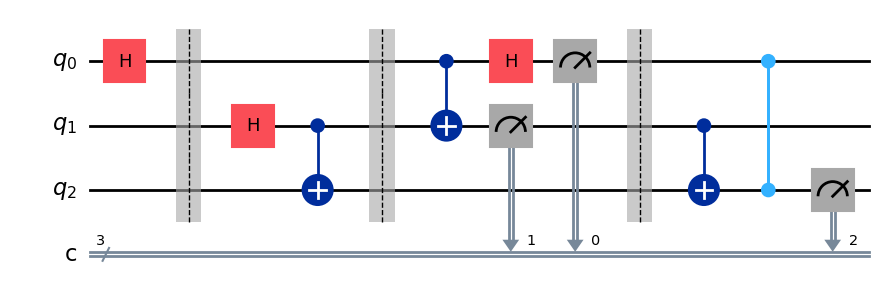

In [3]:
circuit.draw('mpl')

### Simulación

In [4]:
simulator = AerSimulator()
compiled = transpile(circuit, simulator)
result = simulator.run(compiled, shots=100).result()
counts = result.get_counts()

print("Conteos completos (c2 c1 c0):")
print(counts)

Conteos completos (c2 c1 c0):
{'001': 10, '110': 17, '011': 14, '010': 14, '000': 13, '111': 14, '101': 12, '100': 6}


### Histograma — Q2 (Bob)

Qiskit devuelve el resultado de los 3 bits como una cadena `c2c1c0` (el bit más significativo a la izquierda).
Para aislar solo el resultado de Bob (c[2] = carácter de la izquierda), agregamos los conteos sobre los bits de Alice.

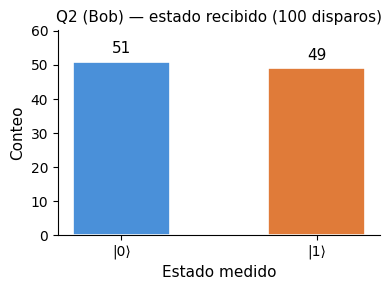

In [5]:
from qml_santanu.common.plot_utils import plot_counts

# Aislar el bit de Bob (posición más significativa en la cadena de 3 bits)
bob_counts = {}
for bitstring, count in counts.items():
    bob_bit = bitstring[0]  # c[2]: bit de Q2
    bob_counts[bob_bit] = bob_counts.get(bob_bit, 0) + count

plot_counts(bob_counts, title='Q2 (Bob) — estado recibido')

### Experimento: distintos estados de Alice

| Operador | Estado transmitido | Resultado esperado en Q2 |
|---|---|---|
| `'H'` | $\|+\rangle = \frac{1}{\sqrt{2}}(\|0\rangle+\|1\rangle)$ | ~50% \|0⟩, ~50% \|1⟩ |
| `'I'` | $\|0\rangle$ | ~100% \|0⟩ |
| `'X'` | $\|1\rangle$ | ~100% \|1⟩ |


Operador: I


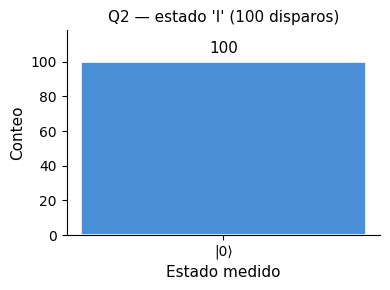


Operador: X


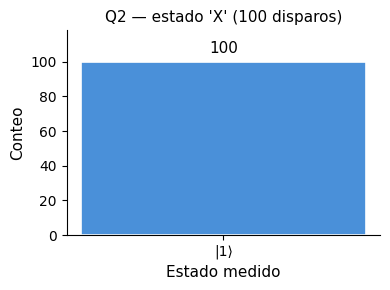

In [6]:
for op in ['I', 'X']:
    c = quantum_teleportation(qubit_to_send_op=op)
    res = simulator.run(transpile(c, simulator), shots=100).result().get_counts()
    bob = {}
    for bitstring, count in res.items():
        bit = bitstring[0]
        bob[bit] = bob.get(bit, 0) + count
    print(f"\nOperador: {op}")
    plot_counts(bob, title=f"Q2 — estado '{op}'")